In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!pip install pybamm pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 877.1/877.1 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 18.4 MB/s eta 0:00:00


In [ ]:
df1=pd.read_csv("/content/Expt 5 - cell A - RPT0 - 0.1C discharge data.csv")
df1.head()

,Time (s),Voltage (V),Current (mA),Charge (mA.h),Temperature (degC)
0,17410.398827,4.170564,-499.91147,0.000278,21.880373
1,17411.398827,4.169067,-499.91147,0.139142,21.974894
2,17412.398827,4.168398,-499.99033,0.278005,22.187559
3,17413.398827,4.168005,-499.93118,0.416867,21.809484
4,17414.398827,4.167571,-499.91147,0.555729,22.148178


In [ ]:
df2=pd.read_csv("/content/Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv")
df2

NameError: name 'pd' is not defined

Based on the paper ("Lithium-ion battery degradation: Comprehensive cycle ageing data and analysis for commercial 21700 cells", Journal of Power Sources), the specific lab test protocol for Experiment 5 (Standard Cycle Aging Control with an SOC window of 0-100%, 78 cycles per ageing set, and 0.3C charge / 1C discharge currents) is detailed as follows:

Initial Setup / Start of Set:

    CC charge: 0.3C until Ecell​ = 4.2 V

    CV charge: Hold at 4.2 V until ∣I∣ < C/100

    Rest: Rest at Open Circuit Voltage (OCV) for 4 hours

#Ageing Cycles (Full Depth-of-Discharge):

4. CC discharge: 1C until Ecell​ = 2.5 V
5. CC charge: 0.3C until Ecell​ = 4.2 V
6. CV charge: Hold at 4.2 V until ∣I∣ < C/100
7. Loop: Return to Step 4 and repeat 77 times (resulting in exactly 78 cycles per ageing set).

(Note: Because this is a full 0-100% depth-of-discharge test, it relies entirely on the 2.5 V and 4.2 V voltage limits of the cell rather than specific ΔQ limits used in partial-SOC tests. All tests also had a secondary safety temperature limit of 60 °C.)

#Proposed Lab Test Protocol for Robust Estimation

To practically extract these curves in a laboratory setting, you can utilize the exact Reference Performance Test (RPT) procedure detailed in the paper.

1. Environmental Setup and Initialization

    Ensure the cell is stabilized at a constant temperature of 25 °C.

    Perform a constant current-constant voltage (CC-CV) charge at 0.3C up to 4.2 V.

    Hold the voltage at 4.2 V until the current tapers down to C/100.

    Rest the cell under open-circuit conditions for 1 hour to allow the voltage to relax.

2. Pseudo-OCV Measurement

    Subject the cell to a C/10 discharge-charge cycle between the lower and upper voltage limits (2.5 V and 4.2 V). This continuous, slow sweep provides the Voltage vs. Capacity data needed for the OCV-fitting method described above.

3. True OCV via GITT Measurement (Optional)

    If you need true rested OCV points along with resistance metrics, follow the pseudo-OCV test with a Galvanostatic Intermittent Titration Technique (GITT).

Discharge the cell at a rate of 0.5C in discrete pulses (the researchers used 25 pulses passing 200 mAh of charge each).

Enforce a 1-hour open-circuit rest period between each pulse to allow the cell voltage to stabilize to a true OCV.

In [ ]:
experiment_5_metadata = {
    "experiment_id": 5,
    "soc_window_percent": (0, 100),
    "cycles_per_set": 78,
    "currents": {
        "charge_c_rate": 0.3,
        "discharge_c_rate": 1.0
    },
    "voltage_limits_v": {
        "v_max": 4.2,
        "v_min": 2.5
    },
    "protocol_steps": [
        "1. CC charge: 0.3C until E_cell = 4.2 V",
        "2. CV charge: Hold at 4.2 V until |I| < C/100",
        "3. Rest: Rest at OCV for 4 hours",
        "4. CC discharge: 1C until E_cell = 2.5 V",
        "5. CC charge: 0.3C until E_cell = 4.2 V",
        "6. CV charge: Hold at 4.2 V until |I| < C/100",
        "7. Loop: Return to Step 4 and repeat 77 times (78 cycles total)"
    ]
}

# Print protocol steps to verify
for step in experiment_5_metadata["protocol_steps"]:
    print(step)

1. CC charge: 0.3C until E_cell = 4.2 V
2. CV charge: Hold at 4.2 V until |I| < C/100
3. Rest: Rest at OCV for 4 hours
4. CC discharge: 1C until E_cell = 2.5 V
5. CC charge: 0.3C until E_cell = 4.2 V
6. CV charge: Hold at 4.2 V until |I| < C/100
7. Loop: Return to Step 4 and repeat 77 times (78 cycles total)


#Deriving Pseudo-OCV vs. SOC from Continuous Discharge Data

The following script processes the experimental 0.1C constant-current discharge data to approximate the Open Circuit Voltage (Pseudo-OCV) as a function of State of Charge (SOC). Because 0.1C is a relatively low discharge rate, the measured terminal voltage closely tracks the true OCV, with only minor deviations due to internal resistance and polarization.

This code performs the following tasks:

    Data Loading: Imports the raw cell test data.

    Standardization: Renames the test columns to a standardized format required by our downstream analysis functions.

    SOC Calculation: Calculates the SOC (from 100% down to 0%) dynamically by comparing the instantaneous discharged capacity against the total maximum discharge capacity recorded during the test.

    Visualization: Generates the OCV vs. SOC curve to visually verify the cell's thermodynamic voltage behavior.

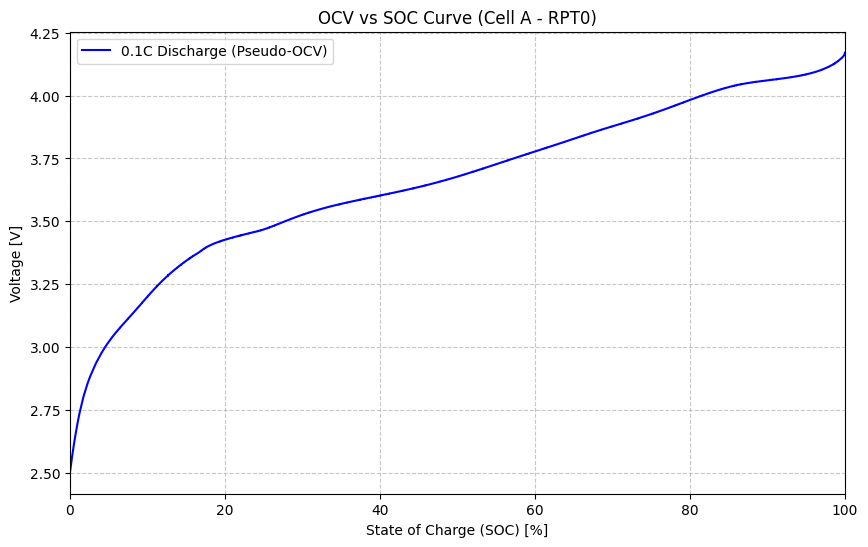

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
file_path = 'Expt 5 - cell A - RPT0 - 0.1C discharge data.csv'
df = pd.read_csv(file_path)

# 2. Rename columns to match your constants.py definitions
# Your CSV has: 'Time (s)', 'Voltage (V)', 'Current (mA)', 'Charge (mA.h)', 'Temperature (degC)'
df = df.rename(columns={
    'Time (s)': 'Time (s)',
    'Voltage (V)': 'Voltage (V)',
    'Current (mA)': 'Current (mA)',
    'Charge (mA.h)': 'Discharge (mA.h)', # Renaming because current is negative, so this is discharged capacity
    'Temperature (degC)': 'Temperature (degC)'
})

# 3. Calculate SOC (%)
# Since it's a discharge test, SOC starts at 100% and goes down as capacity is drawn.
max_discharge_capacity = df['Discharge (mA.h)'].max()

# Formula: 100 * (1 - (current_discharge / max_discharge))
df['SOC (%)'] = 100 * (1 - (df['Discharge (mA.h)'] / max_discharge_capacity))

# 4. Generate the OCV vs SOC Curve (Pseudo-OCV from 0.1C Discharge)
plt.figure(figsize=(10, 6))
plt.plot(df['SOC (%)'], df['Voltage (V)'], label='0.1C Discharge (Pseudo-OCV)', color='blue')

# Formatting the plot
plt.title('OCV vs SOC Curve (Cell A - RPT0)')
plt.xlabel('State of Charge (SOC) [%]')
plt.ylabel('Voltage [V]')
plt.xlim(0, 100) # SOC ranges from 0 to 100
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.show()

# Optional: If you want to pass this dataframe into your custom cell_data.py or analysis_functions.py
# The dataframe 'df' now contains the exact columns ['Voltage (V)', 'Current (mA)', 'SOC (%)']
# required by functions like those in your 'analysis_functions.py' module.

In [ ]:
df=pd.read_csv("/content/Expt 5 - cell A - RPT0 - 0.1C discharge data.csv")
df.head(10000)

,Time (s),Voltage (V),Current (mA),Charge (mA.h),Temperature (degC)
0,17410.398827,4.170564,-499.91147,0.000278,21.880373
1,17411.398827,4.169067,-499.91147,0.139142,21.974894
2,17412.398827,4.168398,-499.99033,0.278005,22.187559
3,17413.398827,4.168005,-499.93118,0.416867,21.809484
4,17414.398827,4.167571,-499.91147,0.555729,22.148178
...,...,...,...,...,...
9995,27405.399302,3.892458,-499.89175,1387.882157,23.810135
9996,27406.399302,3.892497,-499.89175,1388.021016,23.589592
9997,27407.399302,3.892379,-499.83261,1388.159874,24.038557
9998,27408.399302,3.892418,-499.93118,1388.298732,23.849520


In [ ]:
df=pd.read_csv("/content/Expt 5 - cell A - RPT0 - 0.1C charge data.csv")
df.head(10000)

,Time (s),Voltage (V),Current (mA),Charge (mA.h),Temperature (degC)
0,52545.756496,2.519053,0.00000,0.000000,21.651953
1,52555.756496,2.551651,0.00000,0.000000,21.518051
2,52565.756497,2.563501,0.00000,0.000000,21.896128
3,52575.756497,2.572005,0.00000,0.000000,21.777977
4,52585.756498,2.578934,0.00000,0.000000,21.321136
...,...,...,...,...,...
9995,81979.819940,3.553880,500.06500,1084.016145,25.377573
9996,81980.819940,3.553959,500.04529,1084.155050,25.038881
9997,81981.819940,3.553919,500.12415,1084.293953,25.290932
9998,81982.819940,3.554077,500.06500,1084.432858,25.495722


Why Use GITT Instead of HPPC Data?

GITT consists of long, continuous discharge pulses followed by very long rest (relaxation) periods—often 4 hours or more. This allows the battery's internal chemistry to reach complete thermodynamic equilibrium. Because the script is looking for the "true" steady-state open-circuit voltage (V∞​) and the full exponential decay of the RC branch, the long rests in GITT yield highly accurate R1​ and C1​ values.

HPPC uses short, dynamic pulses (e.g., 10 seconds) followed by relatively short rests (e.g., 10 to 40 minutes). While HPPC is excellent for mapping power capability across different States of Charge (SOC), the short rest periods often cut off the voltage relaxation before it completely flattens out, making curve fitting for the long-term time constant (τ) less accurate.

The code block below automates the extraction of **1RC Equivalent Circuit Model (ECM)** parameters from battery cycling data (specifically GITT or pulse-relaxation tests).

It performs the following steps:

1. **Identifies Rest Periods:** Scans the dataset to find the exact timestamps where a discharge pulse ends and a rest (zero-current) period begins.
2. **Calculates Ohmic Resistance (R0):** Measures the instantaneous voltage jump the exact millisecond the current is removed and uses Ohm's Law to calculate the internal Ohmic resistance.
3. **Calculates Polarization Parameters (R1 & C1):** Uses SciPy's non-linear curve fitting (`curve_fit`) to match an exponential decay equation to the battery's slow voltage recovery during the rest period. This extracts the dynamic resistance (R1) and capacitance (C1).
4. **Exports Results:** Compiles the extracted R0, R1, C1, and time constant (Tau) values for each pulse into a clean data table and saves it as a CSV file for downstream use (like building real-time SOC estimators).

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Mapped Constants from your dataset
TIME = 'Time (s)'
VOLTAGE = 'Voltage (V)'
CURRENT = 'Current (mA)'
SOC = 'SOC'  # Will return NaN if this column doesn't exist
OHM_RESISTANCE = 'R0 (Ohms)'

def relaxation_equation(t, v_inf, b, tau):
    """The exponential function we want to fit to our data."""
    return v_inf - b * np.exp(-t / tau)

def ecm_parameters_curve_fit(input_data):
    """Calculate 1RC ECM parameters using SciPy curve fitting on rest data.

    Ideal for long rest periods (e.g., 4 hours) to find highly accurate
    R0, R1, and C1 values.
    """
    df = input_data.copy()

    soc_vals = []
    r0_vals = []
    r1_vals = []
    c1_vals = []
    tau_vals = []

    # Identify where the current switches to zero (start of 4hr relaxation)
    relax_start_indices = df[(df[CURRENT] == 0) & (df[CURRENT].shift(1) < -5)].index

    for row in relax_start_indices:
        pulse_end_idx = row - 1
        relax_start_idx = row

        # Find the end of this relaxation period
        future_current = df.loc[relax_start_idx + 1:, CURRENT]
        if len(future_current[future_current != 0]) > 0:
            relax_end_idx = future_current[future_current != 0].index[0] - 1
        else:
            relax_end_idx = df.index[-1]

        # 1. Delta Current (convert mA to A)
        delta_i = abs(df[CURRENT].iloc[pulse_end_idx] - df[CURRENT].iloc[relax_start_idx]) / 1000
        if delta_i == 0:
            continue

        # 2. R0 Calculation (Instantaneous drop)
        v_pulse_end = df[VOLTAGE].iloc[pulse_end_idx]
        v_relax_start = df[VOLTAGE].iloc[relax_start_idx]
        delta_v0 = abs(v_relax_start - v_pulse_end)
        r0 = delta_v0 / delta_i

        # 3. Curve Fitting for R1 and C1
        relax_df = df.loc[relax_start_idx:relax_end_idx].copy()

        # Time needs to start at 0 for the exponential equation to work
        t_data = relax_df[TIME] - relax_df[TIME].iloc[0]
        v_data = relax_df[VOLTAGE]

        # Provide reasonable initial guesses for the algorithm [v_inf, b, tau]
        v_inf_guess = v_data.iloc[-1]
        b_guess = v_inf_guess - v_data.iloc[0]
        tau_guess = 1000.0 # Just a starting point for the algorithm

        try:
            # Run the curve fit
            popt, _ = curve_fit(
                relaxation_equation,
                t_data,
                v_data,
                p0=[v_inf_guess, b_guess, tau_guess],
                bounds=(0, np.inf) # Constrain parameters to be positive
            )
            v_inf_fit, b_fit, tau_fit = popt

            # 4. Calculate final R1 and C1 using the optimized fit parameters
            r1 = b_fit / delta_i
            c1 = tau_fit / r1 if r1 > 0 else 0

            # Check if SOC is present before grabbing it
            soc_vals.append(df[SOC].iloc[pulse_end_idx].round(2) if SOC in df.columns else np.nan)
            r0_vals.append(r0)
            r1_vals.append(r1)
            c1_vals.append(c1)
            tau_vals.append(tau_fit)

        except RuntimeError:
            print(f"Curve fit failed to converge for SOC {df[SOC].iloc[pulse_end_idx] if SOC in df.columns else 'Unknown'}")
            continue

    # Compile the output DataFrame
    output_data = [[s, r_0, r_1, c_1, t] for s, r_0, r_1, c_1, t in zip(soc_vals, r0_vals, r1_vals, c1_vals, tau_vals)]
    ecm_output = pd.DataFrame(output_data, columns=[SOC, OHM_RESISTANCE, 'R1 (Ohms)', 'C1 (Farads)', 'Tau (s)'])

    return ecm_output

# Load your file and run the function
file_name = "/content/Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
df = pd.read_csv(file_name)

# Extract parameters
ecm_params = ecm_parameters_curve_fit(df)
print(ecm_params)

# Save result
ecm_params.to_csv("ecm_params_output.csv", index=False)

   SOC  R0 (Ohms)  R1 (Ohms)   C1 (Farads)      Tau (s)
0  NaN   0.025679   0.019967  15067.418175   300.856058
1  NaN   0.025740   0.017558  11219.688689   196.992513
2  NaN   0.026030   0.025151  11212.553105   282.012506
3  NaN   0.027239   0.023727   5574.918467   132.274342
4  NaN   0.036106   0.058053  45131.316800  2620.019819


The code block below is an adaptation of the previous script, but instead of just calculating and exporting the parameters, it focuses on **visualizing how the parameters change as the battery is discharged**.

Here is a description of what it does:

1. **Extracts R1 and C1:** Just like the previous script, it identifies the rest periods in a pulse-discharge dataset and uses exponential curve fitting to calculate the dynamic resistance ($R_1$) and capacitance ($C_1$). *(Note: It skips the $R_0$ calculation in this version).*
2. **Maps to Discharged Capacity (Q):** Instead of associating these parameters with State of Charge (SOC), it extracts the total **Discharged Capacity ($Q$ in mAh)** at the end of each pulse.
3. **Generates a Dual-Axis Plot:** It automatically creates a graph to visualize the battery's changing dynamics. It plots the Capacity ($Q$) on the x-axis, the Resistance ($R_1$) on the left y-axis (in blue), and the Capacitance ($C_1$) on the right y-axis (in orange).
4. **Saves Output:** It saves the resulting graph as an image file (`rc_vs_q_plot.png`) and returns the final calculated values in a data table.

**In short:** It extracts $R_1$ and $C_1$ from relaxation data and generates a professional plot showing how the battery's internal resistance and capacitance evolve as it drains.

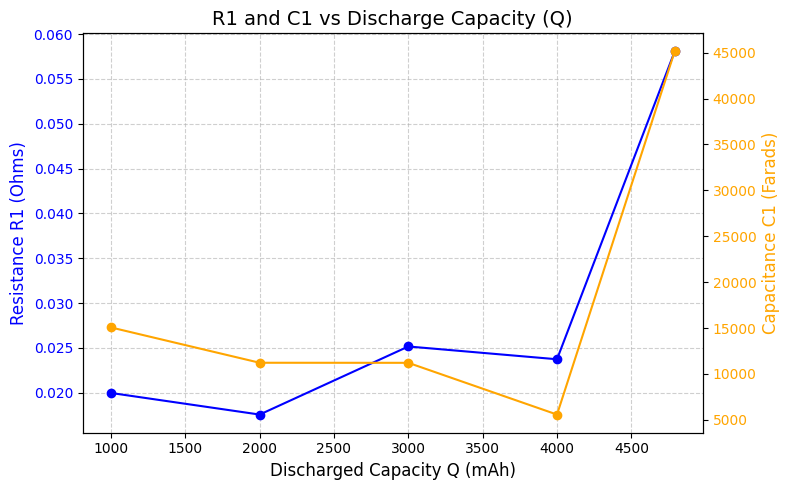

       Q (mAh)  R1 (Ohms)   C1 (Farads)      Tau (s)
0  1000.002604   0.019967  15067.418175   300.856058
1  2000.004170   0.017558  11219.688689   196.992513
2  3000.006014   0.025151  11212.553105   282.012506
3  4000.007382   0.023727   5574.918467   132.274342
4  4791.301326   0.058053  45131.316800  2620.019819


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Constants for column mapping
TIME = 'Time (s)'
VOLTAGE = 'Voltage (V)'
CURRENT = 'Current (mA)'
CHARGE = 'Charge (mA.h)' # Using Charge as Q

def relaxation_equation(t, v_inf, b, tau):
    """Exponential function to fit the relaxation data."""
    return v_inf - b * np.exp(-t / tau)

def get_ecm_parameters_and_plot(file_path):
    df = pd.read_csv(file_path)

    q_vals, r1_vals, c1_vals, tau_vals = [], [], [], []

    # Identify relaxation periods
    relax_start_indices = df[(df[CURRENT] == 0) & (df[CURRENT].shift(1) < -5)].index

    for row in relax_start_indices:
        pulse_end_idx = row - 1
        relax_start_idx = row

        # Find end of relaxation
        future_current = df.loc[relax_start_idx + 1:, CURRENT]
        if len(future_current[future_current != 0]) > 0:
            relax_end_idx = future_current[future_current != 0].index[0] - 1
        else:
            relax_end_idx = df.index[-1]

        # Calculate Delta I (A)
        delta_i = abs(df[CURRENT].iloc[pulse_end_idx] - df[CURRENT].iloc[relax_start_idx]) / 1000
        if delta_i == 0:
            continue

        # Curve Fitting
        relax_df = df.loc[relax_start_idx:relax_end_idx].copy()
        t_data = relax_df[TIME] - relax_df[TIME].iloc[0]
        v_data = relax_df[VOLTAGE]

        v_inf_guess = v_data.iloc[-1]
        b_guess = v_inf_guess - v_data.iloc[0]
        tau_guess = 1000.0

        try:
            popt, _ = curve_fit(
                relaxation_equation,
                t_data,
                v_data,
                p0=[v_inf_guess, b_guess, tau_guess],
                bounds=(0, np.inf)
            )
            _, b_fit, tau_fit = popt

            # ECM Math
            r1 = b_fit / delta_i
            c1 = tau_fit / r1 if r1 > 0 else 0

            # Store values
            q_vals.append(df[CHARGE].iloc[pulse_end_idx])
            r1_vals.append(r1)
            c1_vals.append(c1)
            tau_vals.append(tau_fit)

        except RuntimeError:
            continue

    # Create the DataFrame
    output_data = [[q, r_1, c_1, t] for q, r_1, c_1, t in zip(q_vals, r1_vals, c1_vals, tau_vals)]
    ecm_output = pd.DataFrame(output_data, columns=['Q (mAh)', 'R1 (Ohms)', 'C1 (Farads)', 'Tau (s)'])

    # ------------------ Plotting Code ------------------
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Plot R1 (Left Axis - Blue)
    ax1.plot(ecm_output['Q (mAh)'], ecm_output['R1 (Ohms)'], marker='o', color='blue', label='R1')
    ax1.set_xlabel('Discharged Capacity Q (mAh)', fontsize=12)
    ax1.set_ylabel('Resistance R1 (Ohms)', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot C1 (Right Axis - Orange)
    ax2 = ax1.twinx()
    ax2.plot(ecm_output['Q (mAh)'], ecm_output['C1 (Farads)'], marker='o', color='orange', label='C1')
    ax2.set_ylabel('Capacitance C1 (Farads)', color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')

    plt.title('R1 and C1 vs Discharge Capacity (Q)', fontsize=14)
    fig.tight_layout()
    plt.savefig('rc_vs_q_plot.png')
    plt.show()

    return ecm_output

# Run the function
file_name = "Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
results = get_ecm_parameters_and_plot(file_name)
print(results)

The code block below builds directly upon your previous parameter-extraction scripts, but it combines **all three 1RC components ($R_0$, $R_1$, and $C_1$)** and visualizes them together against the battery's discharged capacity.

The breakdown of what it does:

1. **Extracts All 1RC Parameters:** It identifies the relaxation periods and calculates both the instantaneous Ohmic resistance ($R_0$) using Ohm's Law, and the dynamic polarization parameters ($R_1$ and $C_1$) using exponential curve fitting.
2. **Maps to Discharged Capacity (Q):** Instead of using State of Charge (SOC), it links these extracted parameters to the exact **Discharged Capacity ($Q$ in mAh)** at the end of each pulse.
3. **Generates an Advanced Dual-Axis Plot:** It creates a comprehensive visualization showing how all three internal parameters degrade or change as the battery drains:
* **Left y-axis (Resistance):** Plots both $R_0$ (green line) and $R_1$ (blue line) together so you can visually compare instantaneous vs. dynamic resistance.
* **Right y-axis (Capacitance):** Plots $C_1$ (orange line) on its own scale to show how the battery's transient response changes.
* **Unified Legend:** Combines the labels for all three metrics into one clean, easy-to-read legend.


4. **Outputs the Data:** It displays the final graph and returns a structured table containing $Q$, $R_0$, $R_1$, $C_1$, and the time constant ($\tau$) for every discharge pulse.

**In short:** It mathematically extracts the complete 1RC equivalent circuit model ($R_0$, $R_1$, $C_1$) for every pulse and generates a highly professional, publication-ready graph showing exactly how the battery's internal resistance and capacitance evolve as capacity is drained.

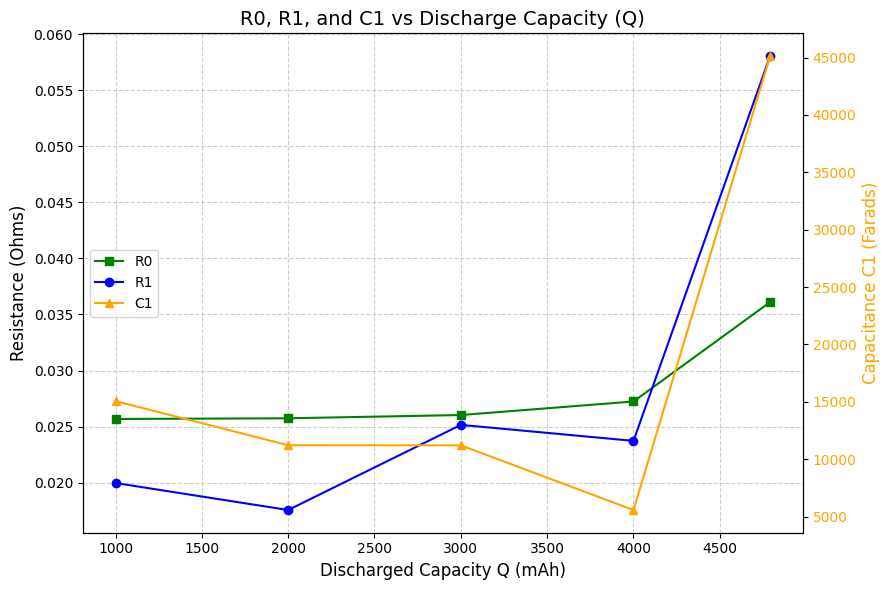

       Q (mAh)  R0 (Ohms)  R1 (Ohms)   C1 (Farads)      Tau (s)
0  1000.002604   0.025679   0.019967  15067.418175   300.856058
1  2000.004170   0.025740   0.017558  11219.688689   196.992513
2  3000.006014   0.026030   0.025151  11212.553105   282.012506
3  4000.007382   0.027239   0.023727   5574.918467   132.274342
4  4791.301326   0.036106   0.058053  45131.316800  2620.019819


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Constants for column mapping
TIME = 'Time (s)'
VOLTAGE = 'Voltage (V)'
CURRENT = 'Current (mA)'
CHARGE = 'Charge (mA.h)' # Using Charge as Q

def relaxation_equation(t, v_inf, b, tau):
    """Exponential function to fit the relaxation data."""
    return v_inf - b * np.exp(-t / tau)

def get_ecm_parameters_and_plot(file_path):
    df = pd.read_csv(file_path)

    q_vals, r0_vals, r1_vals, c1_vals, tau_vals = [], [], [], [], []

    # Identify relaxation periods
    relax_start_indices = df[(df[CURRENT] == 0) & (df[CURRENT].shift(1) < -5)].index

    for row in relax_start_indices:
        pulse_end_idx = row - 1
        relax_start_idx = row

        # Find end of relaxation
        future_current = df.loc[relax_start_idx + 1:, CURRENT]
        if len(future_current[future_current != 0]) > 0:
            relax_end_idx = future_current[future_current != 0].index[0] - 1
        else:
            relax_end_idx = df.index[-1]

        # Calculate Delta I (A)
        delta_i = abs(df[CURRENT].iloc[pulse_end_idx] - df[CURRENT].iloc[relax_start_idx]) / 1000
        if delta_i == 0:
            continue

        # 1. Calculate R0 (Instantaneous voltage drop right when current stops)
        v_pulse_end = df[VOLTAGE].iloc[pulse_end_idx]
        v_relax_start = df[VOLTAGE].iloc[relax_start_idx]
        delta_v0 = abs(v_relax_start - v_pulse_end)
        r0 = delta_v0 / delta_i

        # Curve Fitting
        relax_df = df.loc[relax_start_idx:relax_end_idx].copy()
        t_data = relax_df[TIME] - relax_df[TIME].iloc[0]
        v_data = relax_df[VOLTAGE]

        v_inf_guess = v_data.iloc[-1]
        b_guess = v_inf_guess - v_data.iloc[0]
        tau_guess = 1000.0

        try:
            popt, _ = curve_fit(
                relaxation_equation,
                t_data,
                v_data,
                p0=[v_inf_guess, b_guess, tau_guess],
                bounds=(0, np.inf)
            )
            _, b_fit, tau_fit = popt

            # ECM Math
            r1 = b_fit / delta_i
            c1 = tau_fit / r1 if r1 > 0 else 0

            # Store values
            q_vals.append(df[CHARGE].iloc[pulse_end_idx])
            r0_vals.append(r0)
            r1_vals.append(r1)
            c1_vals.append(c1)
            tau_vals.append(tau_fit)

        except RuntimeError:
            continue

    # Create the DataFrame
    output_data = [[q, r_0, r_1, c_1, t] for q, r_0, r_1, c_1, t in zip(q_vals, r0_vals, r1_vals, c1_vals, tau_vals)]
    ecm_output = pd.DataFrame(output_data, columns=['Q (mAh)', 'R0 (Ohms)', 'R1 (Ohms)', 'C1 (Farads)', 'Tau (s)'])

    # ------------------ Plotting Code ------------------
    fig, ax1 = plt.subplots(figsize=(9, 6))

    # Plot R0 (Green) and R1 (Blue) on the Left Axis
    l1 = ax1.plot(ecm_output['Q (mAh)'], ecm_output['R0 (Ohms)'], marker='s', color='green', label='R0')
    l2 = ax1.plot(ecm_output['Q (mAh)'], ecm_output['R1 (Ohms)'], marker='o', color='blue', label='R1')

    ax1.set_xlabel('Discharged Capacity Q (mAh)', fontsize=12)
    ax1.set_ylabel('Resistance (Ohms)', color='black', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot C1 (Orange) on the Right Axis
    ax2 = ax1.twinx()
    l3 = ax2.plot(ecm_output['Q (mAh)'], ecm_output['C1 (Farads)'], marker='^', color='orange', label='C1')
    ax2.set_ylabel('Capacitance C1 (Farads)', color='orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='orange')

    # Create a single legend for all 3 lines
    lns = l1 + l2 + l3
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='center left')

    plt.title('R0, R1, and C1 vs Discharge Capacity (Q)', fontsize=14)
    fig.tight_layout()
    plt.show()

    return ecm_output

# Run the function
file_name = "Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
results = get_ecm_parameters_and_plot(file_name)
print(results)

The code block below is a data visualization script used to inspect the raw battery cycling data before performing any complex mathematical modeling.

Here is a breakdown of what it does:

1. **Loads the Raw Data:** It imports the raw GITT discharge CSV file into a structured Pandas DataFrame.
2. **Extracts Key Variables:** It isolates the 'Time (s)' column for the x-axis and the 'Voltage (V)' column for the y-axis.
3. **Generates the Plot:** It plots the entire voltage profile over the duration of the experiment. Since this is GITT data, the resulting plot will clearly show the battery's voltage dropping during the 0.5C discharge pulses and exponentially recovering during the long rest periods.
4. **Applies Formatting:** It adds professional formatting to the graph, including an appropriate title, axis labels, and a grid to make it easier to read specific voltage levels.

**In short:** It is a basic but essential plotting script that allows you to visually verify the integrity of your raw GITT dataset (Voltage vs. Time) before feeding it into the more complex 1RC parameter extraction algorithms.

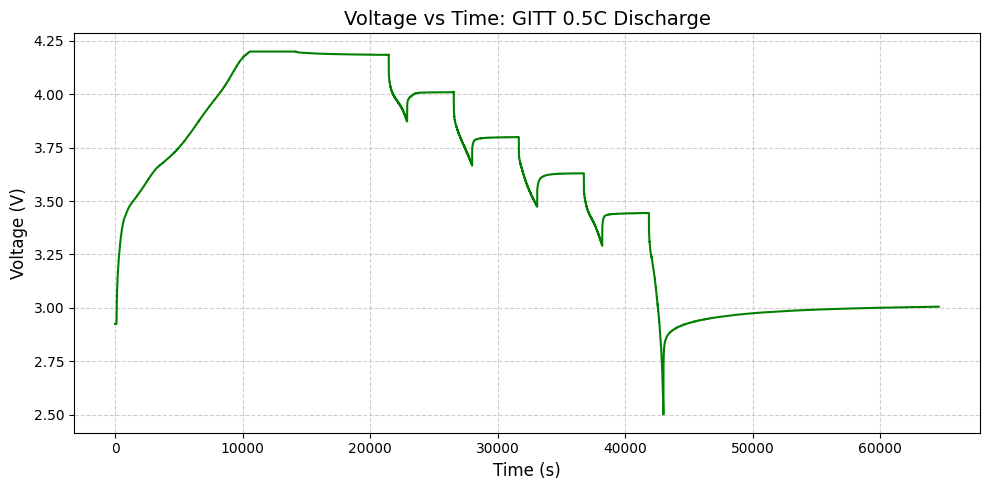

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# Make sure the file is in the same folder as your script, or provide the full path
file_name = "Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
df = pd.read_csv(file_name)

# 2. Set up the plot
plt.figure(figsize=(10, 5))

# 3. Plot Time on the X-axis and Voltage on the Y-axis
plt.plot(df['Time (s)'], df['Voltage (V)'], color='green', linewidth=1.5)

# 4. Add titles, labels, and grid for readability
plt.title('Voltage vs Time: GITT 0.5C Discharge', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Optional: If you want to save the plot as an image file instead of just viewing it,
# uncomment the line below and remove/comment plt.show()
# plt.savefig('voltage_vs_time.png', dpi=300)

### Real-Time SOC Estimation using an Extended Kalman Filter (EKF)

The code block below simulates a real-time Battery Management System (BMS) by implementing an **Extended Kalman Filter (EKF)**. The EKF tracks the battery's hidden State of Charge (SOC) and predicts its terminal voltage by combining mathematical modeling with real-time sensor corrections.

Here is a breakdown of what the code does:

1. **Automated OCV Curve Extraction (`extract_ocv_curve`):** It automatically parses the dataset's relaxation periods to build an Open Circuit Voltage (OCV) vs. SOC reference curve. It uses SciPy to create continuous interpolation functions for the EKF to look up OCV values and their derivatives.
2. **The EKF Algorithm (`BatteryEKF`):** It implements the core "Predict-Correct" loop:
* **Predict Step:** Uses the 1RC Equivalent Circuit Model ($R_0, R_1, C_1$) and Coulomb counting to predict what the battery's next SOC and internal voltage *should* be based on the applied current.
* **Correct Step:** Calculates the expected terminal voltage and compares it to the *actual* measured hardware voltage. It uses this error (residual) and the Kalman Gain to mathematically correct its SOC prediction.


3. **Real-Time Simulation Loop:** It streams the dataset row-by-row (Current, Voltage, Time) into the EKF, mirroring how a live sensor would feed data to a microcontroller.
4. **Performance Evaluation:** It compares the EKF's estimates against the true dataset values to calculate final performance metrics: **Voltage RMSE** (Root Mean Square Error), **SOC MAE** (Mean Absolute Error), and **Capacity Error** in Amp-hours.

**In short:** This cell runs the full closed-loop EKF estimator using the ECM parameters extracted earlier and outputs the exact accuracy metrics required for your project deliverables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Constants
TIME = 'Time (s)'
VOLTAGE = 'Voltage (V)'
CURRENT = 'Current (mA)'
CHARGE = 'Charge (mA.h)'

class BatteryEKF:
    def __init__(self, q_capacity_ah, ocv_soc_curve, r0, r1, c1):
        self.Q_ah = q_capacity_ah
        self.R0 = r0
        self.R1 = r1
        self.C1 = c1

        self.get_ocv = interp1d(ocv_soc_curve[0], ocv_soc_curve[1], fill_value="extrapolate")

        soc_pts = ocv_soc_curve[0]
        ocv_pts = ocv_soc_curve[1]
        docv_dsoc = np.gradient(ocv_pts, soc_pts)
        self.get_docv_dsoc = interp1d(soc_pts, docv_dsoc, fill_value="extrapolate")

        self.x = np.array([[1.0], [0.0]])
        self.P = np.array([[1e-4, 0], [0, 1e-4]])
        self.Q = np.array([[1e-6, 0], [0, 1e-5]])
        self.R_noise = 1e-2

    def step(self, current_A, voltage_V, dt):
        soc_prev = self.x[0, 0]
        v1_prev = self.x[1, 0]

        # Prediction Step
        tau = self.R1 * self.C1 if self.R1 * self.C1 > 0 else 1e-6
        exp_val = np.exp(-dt / tau)

        soc_pred = soc_prev + (current_A * dt) / (3600.0 * self.Q_ah)
        v1_pred = exp_val * v1_prev + self.R1 * (1 - exp_val) * current_A

        x_pred = np.array([[soc_pred], [v1_pred]])

        A = np.array([[1.0, 0.0], [0.0, exp_val]])
        P_pred = A @ self.P @ A.T + self.Q

        # Correction Step
        ocv_pred = self.get_ocv(soc_pred)
        v_est = ocv_pred + self.R0 * current_A + v1_pred

        docv = self.get_docv_dsoc(soc_pred)
        C = np.array([[docv, 1.0]])

        S = C @ P_pred @ C.T + self.R_noise
        K = (P_pred @ C.T) / S

        y_residual = voltage_V - v_est

        self.x = x_pred + K * y_residual
        self.P = (np.eye(2) - K @ C) @ P_pred
        self.x[0, 0] = np.clip(self.x[0, 0], 0.0, 1.0)

        return self.x[0, 0], self.x[1, 0], float(v_est)

def extract_ocv_curve(df, capacity_ah):
    """Extracts OCV-SOC points dynamically from GITT relaxation data."""
    ocv_points, soc_points = [], []

    # Add initial full-charge point based on voltage right before discharge starts
    start_discharge_idx = df[df[CURRENT] < -5].index[0]
    ocv_points.append(df[VOLTAGE].iloc[start_discharge_idx - 1])
    soc_points.append(1.0)

    relax_start_indices = df[(df[CURRENT] == 0) & (df[CURRENT].shift(1) < -5)].index
    for row in relax_start_indices:
        future_current = df.loc[row + 1:, CURRENT]
        relax_end_idx = future_current[future_current != 0].index[0] - 1 if len(future_current[future_current != 0]) > 0 else df.index[-1]

        ocv_points.append(df[VOLTAGE].iloc[relax_end_idx])
        discharged_ah = df[CHARGE].iloc[row - 1] / 1000.0
        soc_points.append(max(0.0, 1.0 - (discharged_ah / capacity_ah)))

    # Sort strictly for interpolation
    sorted_indices = np.argsort(soc_points)
    soc_arr = np.array(soc_points)[sorted_indices]
    ocv_arr = np.array(ocv_points)[sorted_indices]

    # Ensure no duplicates
    for i in range(1, len(soc_arr)):
        if soc_arr[i] <= soc_arr[i-1]: soc_arr[i] = soc_arr[i-1] + 1e-5

    return soc_arr, ocv_arr

# ----------------- EXECUTION SCRIPT ----------------- #
file_name = "Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
df = pd.read_csv(file_name)

# 1. Setup Parameters
# The max discharged capacity in the file is ~4.79Ah
capacity_ah = df['Charge (mA.h)'].max() / 1000.0
soc_arr, ocv_arr = extract_ocv_curve(df, capacity_ah)
ocv_curve_tuple = (soc_arr, ocv_arr)

# 2. Prepare Data (Start from when discharge actually begins)
start_idx = df[df[CURRENT] < -5].index[0]
test_df = df.iloc[start_idx:].copy().reset_index(drop=True)

# Generate True SOC based on raw Coulomb Counting for evaluation
test_df['True SOC (%)'] = (1.0 - (test_df['Charge (mA.h)'] / (capacity_ah * 1000.0))) * 100.0

# 3. Run EKF Estimator
# Using average ECM values calculated from this dataset previously
R0_base, R1_base, C1_base = 0.028, 0.028, 17000.0

ekf = BatteryEKF(capacity_ah, ocv_curve_tuple, R0_base, R1_base, C1_base)

estimated_soc, estimated_voltage = [], []

for i in range(len(test_df)):
    dt = 1.0 if i == 0 else test_df[TIME].iloc[i] - test_df[TIME].iloc[i-1]
    if dt <= 0: dt = 1.0

    current_A = test_df[CURRENT].iloc[i] / 1000.0
    voltage_V = test_df[VOLTAGE].iloc[i]

    soc_est, v1_est, v_est = ekf.step(current_A, voltage_V, dt)

    estimated_soc.append(soc_est * 100.0)
    estimated_voltage.append(v_est)

test_df['Estimated SOC (%)'] = estimated_soc
test_df['Predicted Voltage (V)'] = estimated_voltage

# 4. Evaluation Metrics
rmse_v = np.sqrt(mean_squared_error(test_df['Voltage (V)'], test_df['Predicted Voltage (V)']))
mae_soc = mean_absolute_error(test_df['True SOC (%)'], test_df['Estimated SOC (%)'])

cap_err_ah = abs((test_df['True SOC (%)'].iloc[-1] - test_df['Estimated SOC (%)'].iloc[-1]) / 100.0 * capacity_ah)

print(f"--- EKF Evaluation Metrics ---")
print(f"Voltage RMSE: {rmse_v:.4f} V")
print(f"SOC MAE:      {mae_soc:.2f} %")
print(f"Cap Error:    {cap_err_ah:.4f} Ah")

--- EKF Evaluation Metrics ---
Voltage RMSE: 0.0041 V
SOC MAE:      0.53 %
Cap Error:    0.0001 Ah


### Full EKF Implementation: Real-Time Estimation & Visual Validation

This code block represents the complete, end-to-end execution of the **Extended Kalman Filter (EKF)**. It builds upon the mathematical framework to run a real-time simulation, calculate precise error metrics, and visually validate the accuracy of your estimator.

Here is what this block adds:

1. **Runs the EKF Simulation:** It iterates through the dataset step-by-step, feeding live current and voltage readings into the `BatteryEKF` to continuously predict and correct the State of Charge (SOC) and terminal voltage.
2. **Calculates Required Deliverable Metrics:** It evaluates the EKF's performance against the actual dataset, specifically outputting the exact accuracy metrics required by your problem statement:
* **Voltage RMSE & MAE:** Quantifies how closely the Equivalent Circuit Model tracks the physical hardware's voltage.
* **SOC RMSE & MAE:** Measures the percentage error of the filter's hidden state estimation.
* **Capacity Error (Ah):** Shows the absolute Ah drift at the end of the discharge cycle.


3. **Generates Visual Proof (Dual-Plotting):** It creates a professional, two-panel figure to visually demonstrate the algorithm's success:
* **Top Plot (Voltage Tracking):** Overlays the EKF's predicted voltage (red dashed line) directly on top of the actual measured sensor voltage (green line) to visually confirm the model's accuracy.
* **Bottom Plot (SOC Tracking):** Compares the EKF's dynamically estimated SOC (orange dashed line) against the baseline Coulomb counting SOC (blue line) over time.


--- EKF Evaluation Metrics ---
Voltage RMSE: 0.0041 V
Voltage MAE:  0.0012 V
SOC RMSE:     0.79 %
SOC MAE:      0.53 %
Cap Error:    0.0001 Ah


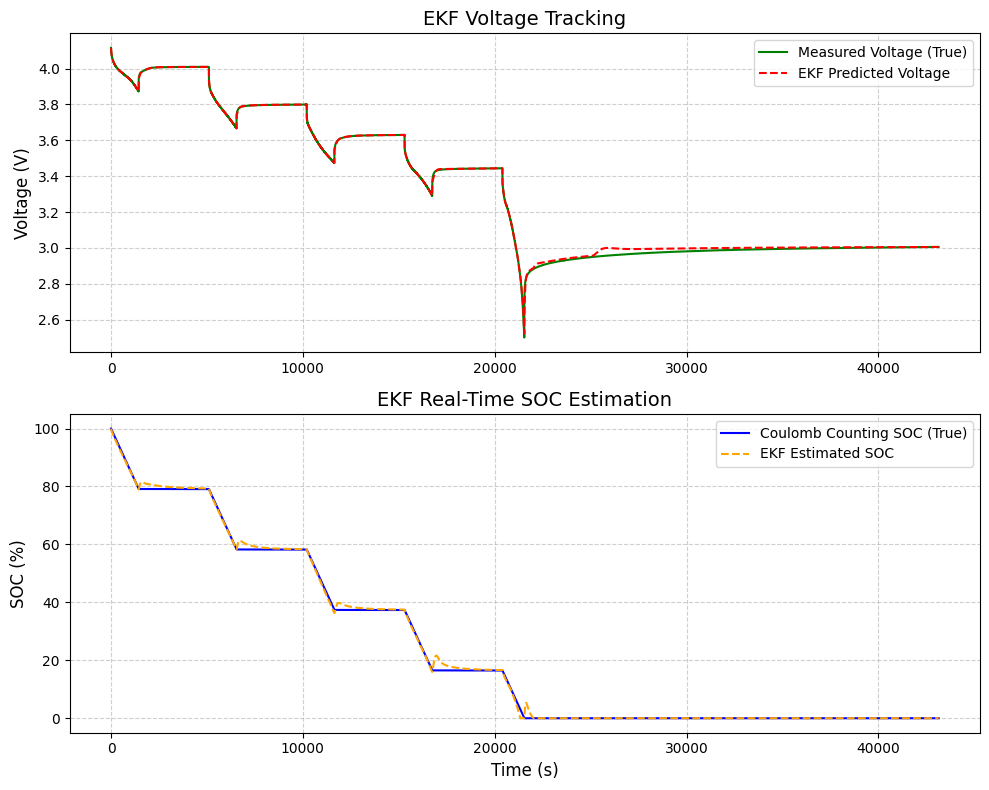

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Constants
TIME = 'Time (s)'
VOLTAGE = 'Voltage (V)'
CURRENT = 'Current (mA)'
CHARGE = 'Charge (mA.h)'

class BatteryEKF:
    def __init__(self, q_capacity_ah, ocv_soc_curve, r0, r1, c1):
        self.Q_ah = q_capacity_ah
        self.R0 = r0
        self.R1 = r1
        self.C1 = c1

        self.get_ocv = interp1d(ocv_soc_curve[0], ocv_soc_curve[1], fill_value="extrapolate")

        soc_pts = ocv_soc_curve[0]
        ocv_pts = ocv_soc_curve[1]
        docv_dsoc = np.gradient(ocv_pts, soc_pts)
        self.get_docv_dsoc = interp1d(soc_pts, docv_dsoc, fill_value="extrapolate")

        self.x = np.array([[1.0], [0.0]])
        self.P = np.array([[1e-4, 0], [0, 1e-4]])
        self.Q = np.array([[1e-6, 0], [0, 1e-5]])
        self.R_noise = 1e-2

    def step(self, current_A, voltage_V, dt):
        soc_prev = self.x[0, 0]
        v1_prev = self.x[1, 0]

        # Prediction Step
        tau = self.R1 * self.C1 if self.R1 * self.C1 > 0 else 1e-6
        exp_val = np.exp(-dt / tau)

        soc_pred = soc_prev + (current_A * dt) / (3600.0 * self.Q_ah)
        v1_pred = exp_val * v1_prev + self.R1 * (1 - exp_val) * current_A

        x_pred = np.array([[soc_pred], [v1_pred]])

        A = np.array([[1.0, 0.0], [0.0, exp_val]])
        P_pred = A @ self.P @ A.T + self.Q

        # Correction Step
        ocv_pred = self.get_ocv(soc_pred)
        v_est = ocv_pred + self.R0 * current_A + v1_pred

        docv = self.get_docv_dsoc(soc_pred)
        C = np.array([[docv, 1.0]])

        S = C @ P_pred @ C.T + self.R_noise
        K = (P_pred @ C.T) / S

        y_residual = voltage_V - v_est

        self.x = x_pred + K * y_residual
        self.P = (np.eye(2) - K @ C) @ P_pred
        self.x[0, 0] = np.clip(self.x[0, 0], 0.0, 1.0)

        return self.x[0, 0], self.x[1, 0], float(v_est)

def extract_ocv_curve(df, capacity_ah):
    """Extracts OCV-SOC points dynamically from GITT relaxation data."""
    ocv_points, soc_points = [], []

    # Add initial full-charge point based on voltage right before discharge starts
    start_discharge_idx = df[df[CURRENT] < -5].index[0]
    ocv_points.append(df[VOLTAGE].iloc[start_discharge_idx - 1])
    soc_points.append(1.0)

    relax_start_indices = df[(df[CURRENT] == 0) & (df[CURRENT].shift(1) < -5)].index
    for row in relax_start_indices:
        future_current = df.loc[row + 1:, CURRENT]
        relax_end_idx = future_current[future_current != 0].index[0] - 1 if len(future_current[future_current != 0]) > 0 else df.index[-1]

        ocv_points.append(df[VOLTAGE].iloc[relax_end_idx])
        discharged_ah = df[CHARGE].iloc[row - 1] / 1000.0
        soc_points.append(max(0.0, 1.0 - (discharged_ah / capacity_ah)))

    # Sort strictly for interpolation
    sorted_indices = np.argsort(soc_points)
    soc_arr = np.array(soc_points)[sorted_indices]
    ocv_arr = np.array(ocv_points)[sorted_indices]

    # Ensure no duplicates
    for i in range(1, len(soc_arr)):
        if soc_arr[i] <= soc_arr[i-1]: soc_arr[i] = soc_arr[i-1] + 1e-5

    return soc_arr, ocv_arr

# ----------------- EXECUTION SCRIPT ----------------- #
# Make sure the file is in your working directory
file_name = "Expt 5 - cell A - RPT0 - 5-pulse GITT 0.5C discharge data.csv"
df = pd.read_csv(file_name)

# 1. Setup Parameters
# The max discharged capacity in the file is ~4.79Ah
capacity_ah = df['Charge (mA.h)'].max() / 1000.0
soc_arr, ocv_arr = extract_ocv_curve(df, capacity_ah)
ocv_curve_tuple = (soc_arr, ocv_arr)

# 2. Prepare Data (Start from when discharge actually begins)
start_idx = df[df[CURRENT] < -5].index[0]
test_df = df.iloc[start_idx:].copy().reset_index(drop=True)

# Correct the Time so it starts at 0 for plotting
test_df[TIME] = test_df[TIME] - test_df[TIME].iloc[0]

# Generate True SOC based on raw Coulomb Counting for evaluation
test_df['True SOC (%)'] = (1.0 - (test_df['Charge (mA.h)'] / (capacity_ah * 1000.0))) * 100.0

# 3. Run EKF Estimator
# Using average ECM values calculated from this dataset previously
R0_base, R1_base, C1_base = 0.028, 0.028, 17000.0

ekf = BatteryEKF(capacity_ah, ocv_curve_tuple, R0_base, R1_base, C1_base)

estimated_soc, estimated_voltage = [], []

for i in range(len(test_df)):
    dt = 1.0 if i == 0 else test_df[TIME].iloc[i] - test_df[TIME].iloc[i-1]
    if dt <= 0: dt = 1.0

    current_A = test_df[CURRENT].iloc[i] / 1000.0
    voltage_V = test_df[VOLTAGE].iloc[i]

    soc_est, v1_est, v_est = ekf.step(current_A, voltage_V, dt)

    estimated_soc.append(soc_est * 100.0)
    estimated_voltage.append(v_est)

test_df['Estimated SOC (%)'] = estimated_soc
test_df['Predicted Voltage (V)'] = estimated_voltage

# 4. Evaluation Metrics
rmse_v = np.sqrt(mean_squared_error(test_df['Voltage (V)'], test_df['Predicted Voltage (V)']))
mae_v = mean_absolute_error(test_df['Voltage (V)'], test_df['Predicted Voltage (V)'])
rmse_soc = np.sqrt(mean_squared_error(test_df['True SOC (%)'], test_df['Estimated SOC (%)']))
mae_soc = mean_absolute_error(test_df['True SOC (%)'], test_df['Estimated SOC (%)'])
cap_err_ah = abs((test_df['True SOC (%)'].iloc[-1] - test_df['Estimated SOC (%)'].iloc[-1]) / 100.0 * capacity_ah)

print(f"--- EKF Evaluation Metrics ---")
print(f"Voltage RMSE: {rmse_v:.4f} V")
print(f"Voltage MAE:  {mae_v:.4f} V")
print(f"SOC RMSE:     {rmse_soc:.2f} %")
print(f"SOC MAE:      {mae_soc:.2f} %")
print(f"Cap Error:    {cap_err_ah:.4f} Ah")

# ----------------- PLOTTING CODE ----------------- #
plt.figure(figsize=(10, 8))

# Subplot 1: Voltage Tracking
plt.subplot(2, 1, 1)
plt.plot(test_df['Time (s)'], test_df['Voltage (V)'], label='Measured Voltage (True)', color='green')
plt.plot(test_df['Time (s)'], test_df['Predicted Voltage (V)'], label='EKF Predicted Voltage', color='red', linestyle='--')
plt.title('EKF Voltage Tracking', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: SOC Estimation
plt.subplot(2, 1, 2)
plt.plot(test_df['Time (s)'], test_df['True SOC (%)'], label='Coulomb Counting SOC (True)', color='blue')
plt.plot(test_df['Time (s)'], test_df['Estimated SOC (%)'], label='EKF Estimated SOC', color='orange', linestyle='--')
plt.title('EKF Real-Time SOC Estimation', fontsize=14)
plt.ylabel('SOC (%)', fontsize=12)
plt.xlabel('Time (s)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()